
# Advanced Training Strategies for Pneumonia Detection in X-Ray Images

This notebook demonstrates how to train a convolutional neural network on the
[Chest X-Ray Pneumonia Dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).

The images in this database are grayscale x-ray images; some example images are pictured below.

<img src='images/pneunomia.png' width=25% />

In [53]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# set random seeds for reproducibility
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
    device = torch.device("cpu")
else:
    print('CUDA is available!  Training on GPU ...')
    device = torch.device("cuda")

CUDA is available!  Training on GPU ...


## Load and Augment the Data

We load in the training, validation and test data, then create DataLoaders for each of these sets of data.


In [54]:
IMG_SIZE = 64  # or 128

# Data transforms and loaders
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder('/data/chest_xray/train', transform=train_transforms)
val_data   = datasets.ImageFolder('/data/chest_xray/val', transform=test_transforms)
test_data  = datasets.ImageFolder('/data/chest_xray/test', transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

classes = train_data.classes
print("Classes:", classes)

Classes: ['NORMAL', 'PNEUMONIA']


### Visualize a Batch of Training Data

In [55]:
# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    img = np.squeeze(img) # remove single-dimensional entries from the shape
    plt.imshow(img, cmap='gray')  # convert from Tensor image

(1, 64, 64)


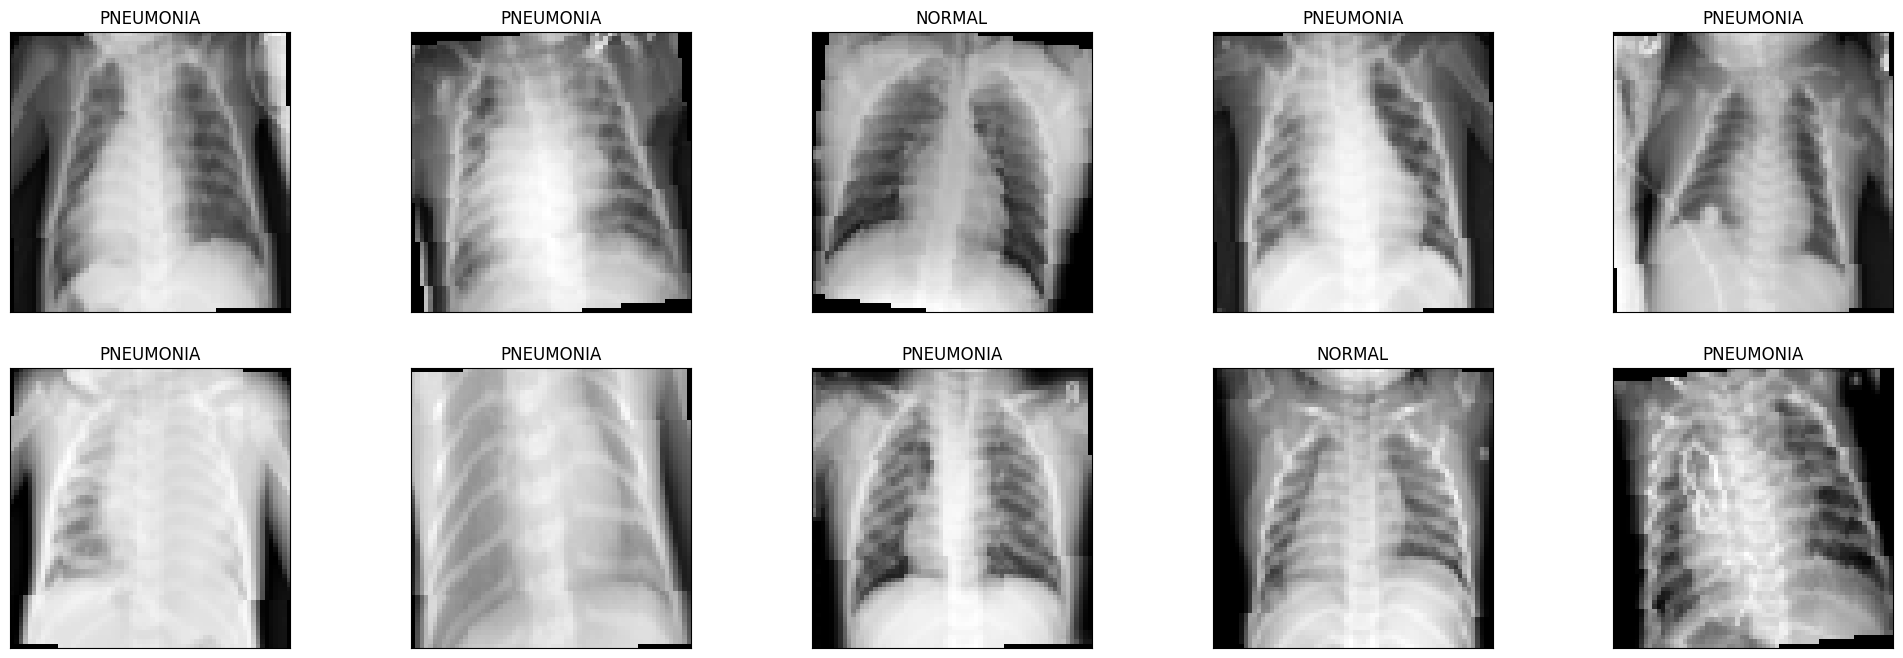

In [56]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 8))
# display 10 images
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

    # take a look at the shape of one image
    if idx == 0:
        print(images[idx].shape) # grayscale image: 1x128x128

## Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)

Now let's define our CNN. A network with two convolutional layers is shown in the image below, and you've been given starter code with two convolutional and two maxpooling layers.

<img src='images/2_layer_conv.png' height=50% width=50% />

In [57]:
# Model definition
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Input size: 1 x IMG_SIZE x IMG_SIZE
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Size after pool: 16 x (IMG_SIZE/2) x (IMG_SIZE/2)
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = PneumoniaCNN().to(device)
print(model)


PneumoniaCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=8192, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


Next, we decide on a loss and optimization function that is best suited for this classification task. 

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train the Network

Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting.

In [59]:
# Training loop
epochs = 4 # we only do a few epochs here for brevity
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs}.. "
          f"Train Loss: {train_losses[-1]:.3f}.. "
          f"Val Loss: {val_losses[-1]:.3f}.. "
          f"Val Acc: {val_acc:.2f}%")

Epoch 1/4.. Train Loss: 0.254.. Val Loss: 0.835.. Val Acc: 75.00%
Epoch 2/4.. Train Loss: 0.129.. Val Loss: 0.631.. Val Acc: 68.75%
Epoch 3/4.. Train Loss: 0.115.. Val Loss: 0.374.. Val Acc: 75.00%
Epoch 4/4.. Train Loss: 0.113.. Val Loss: 1.182.. Val Acc: 56.25%
Runtime training: 248.39 seconds


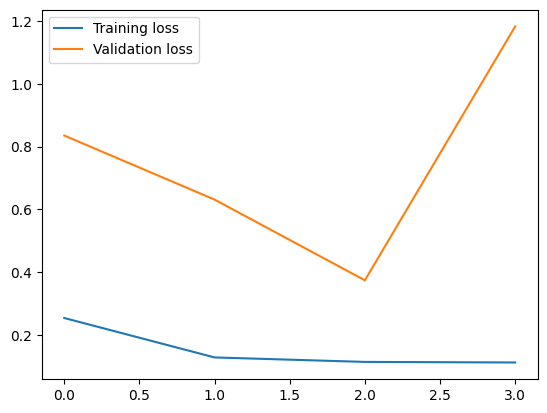

In [60]:

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()


## Test the Trained Network

Test your trained model on previously unseen data! 

In [61]:
# track test loss
test_loss = 0.0
num_classes = len(classes)
class_correct = [0. for _ in range(num_classes)]
class_total = [0. for _ in range(num_classes)]

model.eval()
for batch_idx, (data, target) in enumerate(test_loader):
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    output = model(data)
    loss = criterion(output, target)
    test_loss += loss.item() * data.size(0)
    
    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy()) if train_on_gpu else np.squeeze(correct_tensor.numpy())
    
    for i in range(len(target)):  # <-- robust fix
        label = target.data[i].item()
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(num_classes):
    if class_total[i] > 0:
        print('Test Accuracy of %10s: %2d%% (%2d/%2d)' % (
            classes[i],
            100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %10s: N/A (no examples)' % (classes[i]))

print('\nOverall Test Accuracy: %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))


Test Loss: 1.048144

Test Accuracy of     NORMAL: 25% (59/234)
Test Accuracy of  PNEUMONIA: 99% (389/390)

Overall Test Accuracy: 71% (448/624)


The overall accuracy looks quite good! But wait a minute...

**TODO:** How do you interpret the results? Are there classes that performed better or worse than others? Why do you think that is?

**ANSWER:** We can see that the model performs well on the pneumonia class, but very badly on the normal class. This could be due to several factors, such as class imbalance in the dataset (more pneumonia cases than normal, so the model is biased towards predicting pneumonia), or inherent difficulty in distinguishing between healthy and pneumonia-affected lungs (the images look quite similar). 

### Visualize Sample Test Results

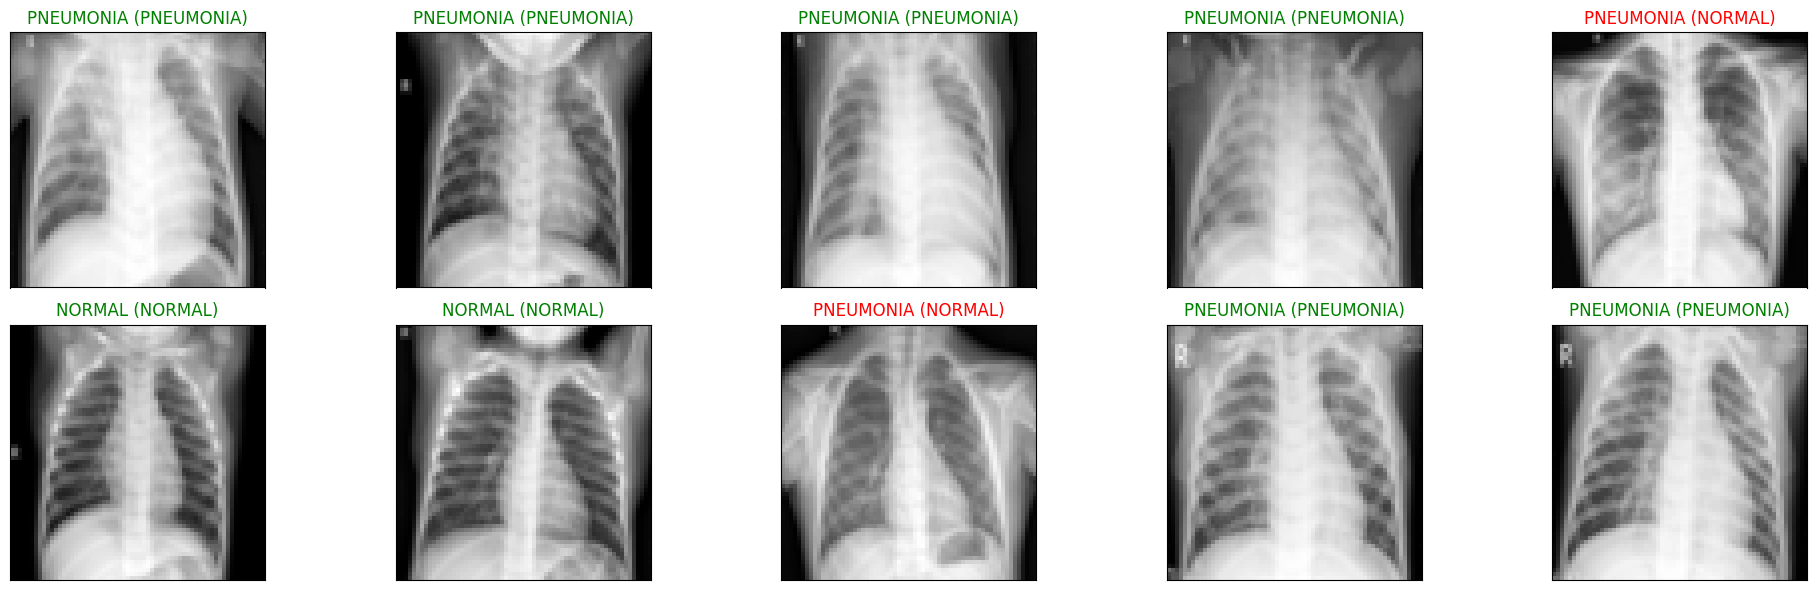

In [62]:
# --- Create a shuffled copy of the test loader just for visualization ---
# (We keep the original test_loader with shuffle=False for evaluation)
test_loader_vis = DataLoader(test_data, batch_size=10, shuffle=True)

# Get one random batch of test images
dataiter = iter(test_loader_vis)
images, labels = next(dataiter)

# Move tensors to GPU if available
images = images.to(device)
labels = labels.to(device)

# --- Run the model on this batch ---
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds_tensor = torch.max(outputs, 1)

# Move predictions and labels back to CPU for plotting
preds = preds_tensor.cpu().numpy()
labels = labels.cpu().numpy()
images = images.cpu().numpy()

# --- Plot images with predicted and true labels ---
fig = plt.figure(figsize=(20, 6))
for idx in np.arange(len(images)):
    ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])
    
    # Unnormalize the image (reverse the normalization)
    img = np.squeeze(images[idx]) * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    
    # Define predicted and true labels
    pred_label = classes[preds[idx]]
    true_label = classes[labels[idx]]
    
    # Color the title: green = correct, red = wrong
    color = "green" if preds[idx] == labels[idx] else "red"
    ax.set_title(f"{pred_label} ({true_label})", color=color)

plt.tight_layout()
plt.show()


Oh no, our model misclassified quite some images! Let's see how we can improve it using advanced training techniques.

---
## Improved Training Techniques

Let's start by adding more data augmentation to increase the data variability, and by using a weighted sampler to reduce class imbalance.

**TODO:** Implement more data augmentation steps below! You can find a list of available transforms [here](https://pytorch.org/vision/0.9/transforms.html). You can for example add a `ColorJitter` or a `RandomAffine` transform.

In [63]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

# --- Enhanced Data Augmentation ---
# YOUR CODE HERE
train_transforms_improved = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # Brightness and contrast adjustment by 30%
    transforms.RandomAffine(0, translate=(0.05, 0.05)), # Slight translation by 5%
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# END STUDENT CODE

test_transforms_improved = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Reload datasets with new transforms
train_data_improved = datasets.ImageFolder('/data/chest_xray/train', transform=train_transforms_improved)
val_data_improved   = datasets.ImageFolder('/data/chest_xray/val', transform=test_transforms_improved)
test_data_improved  = datasets.ImageFolder('/data/chest_xray/test', transform=test_transforms_improved)

# --- Balanced Sampling (alternative to class weights) ---
targets = np.array(train_data_improved.targets)
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weights = 1. / class_sample_count
samples_weights = np.array([weights[t] for t in targets])
sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

batch_size = 32
train_loader_improved = DataLoader(train_data_improved, batch_size=batch_size, sampler=sampler)
val_loader_improved   = DataLoader(val_data_improved, batch_size=batch_size, shuffle=False)
test_loader_improved  = DataLoader(test_data_improved, batch_size=batch_size, shuffle=False)

# --- Class Weights for CrossEntropyLoss ---
counts = Counter(train_data_improved.targets)
class_weights = [1.0 / counts[i] for i in range(len(classes))]
class_weights = torch.FloatTensor(class_weights).to(device)

Now we define an improved model with more regularization. We also use a weighted loss that punishes misclassifications of the rare class more: 

**TODO:** Define an improved model architecture with batch norm and dropout as regularization to reduce overfitting. To keep training time in a reasonable range, you should not make the network deeper unless you have the required hardware available.

In [64]:
# Modified CNN with more Dropout

class PneumoniaCNN_Improved(nn.Module):
    # YOUR CODE HERE
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Input size: 1 x IMG_SIZE x IMG_SIZE
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # Size after pool: 16 x (IMG_SIZE/2) x (IMG_SIZE/2)
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)

        )
        self.fc_layers = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(32 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x
    # END STUDENT CODE

modelB = PneumoniaCNN_Improved().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(modelB.parameters(), lr=0.001)

print(modelB)

PneumoniaCNN_Improved(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Now we implement an improved train loop with early stopping and a learning rate scheduler.

**TODO:** Implement a learning rate scheduler to decrease the learning rate automatically when no improvement is visible anymore. You can find the documentation and an example [here](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html). 

**HINT:** This includes two steps: 1) Define the scheduler and 2) apply it in the train loop below.

In [65]:
# YOUR CODE HERE
# Define Learning Rate Scheduler: reduces LR when val_loss plateaus
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [66]:
# Train Improved Model (with Early Stopping + LR Scheduler)
import copy

epochs = 4 # we only do a few epochs here for brevity
train_losses_B, val_losses_B = [], []

# Early Stopping Parameter
early_stopping_patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(modelB.state_dict())

for epoch in range(epochs):
    modelB.train()
    running_loss = 0.0
    for images, labels in train_loader_improved:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = modelB(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # === Validation ===
    modelB.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_improved:
            images, labels = images.to(device), labels.to(device)
            outputs = modelB(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_loss = running_loss / len(train_loader_improved)
    val_loss = val_loss / len(val_loader_improved)
    val_acc = 100 * correct / total

    train_losses_B.append(train_loss)
    val_losses_B.append(val_loss)

    # YOUR CODE HERE
    # Apply scheduler step
    scheduler.step(val_loss)
    # END STUDENT CODE

    print(f"Epoch {epoch+1}/{epochs}.. "
          f"Train Loss: {train_loss:.3f}.. "
          f"Val Loss: {val_loss:.3f}.. "
          f"Val Acc: {val_acc:.2f}% "
          f"(LR: {optimizer.param_groups[0]['lr']:.5f})")

    # === Early Stopping Check ===
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(modelB.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= early_stopping_patience:
        print("Early stopping triggered!")
        break

# Load best model weights
modelB.load_state_dict(best_model_wts)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Epoch 1/4.. Train Loss: 0.360.. Val Loss: 0.280.. Val Acc: 87.50% (LR: 0.00100)
Epoch 2/4.. Train Loss: 0.214.. Val Loss: 0.255.. Val Acc: 87.50% (LR: 0.00100)
Epoch 3/4.. Train Loss: 0.214.. Val Loss: 0.306.. Val Acc: 87.50% (LR: 0.00100)
No improvement for 1 epoch(s).
Epoch 4/4.. Train Loss: 0.193.. Val Loss: 0.394.. Val Acc: 62.50% (LR: 0.00100)
No improvement for 2 epoch(s).
Training complete. Best val loss: 0.2551
Runtime training: 330.91 seconds


### Test

Now let's see what we have gained:

In [67]:
# track test loss
test_loss = 0.0
num_classes = len(classes)
class_correct = [0. for _ in range(num_classes)]
class_total = [0. for _ in range(num_classes)]

modelB.eval()
for batch_idx, (data, target) in enumerate(test_loader):
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    output = modelB(data)
    loss = criterion(output, target)
    test_loss += loss.item() * data.size(0)
    
    _, pred = torch.max(output, 1)
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.cpu().numpy()) if train_on_gpu else np.squeeze(correct_tensor.numpy())
    
    for i in range(len(target)):  # <-- robust fix
        label = target.data[i].item()
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss / len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(num_classes):
    if class_total[i] > 0:
        print('Test Accuracy of %10s: %2d%% (%2d/%2d)' % (
            classes[i],
            100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %10s: N/A (no examples)' % (classes[i]))

print('\nOverall Test Accuracy: %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))


Test Loss: 0.367580

Test Accuracy of     NORMAL: 79% (187/234)
Test Accuracy of  PNEUMONIA: 87% (340/390)

Overall Test Accuracy: 84% (527/624)


### Visualize Sample Test Results

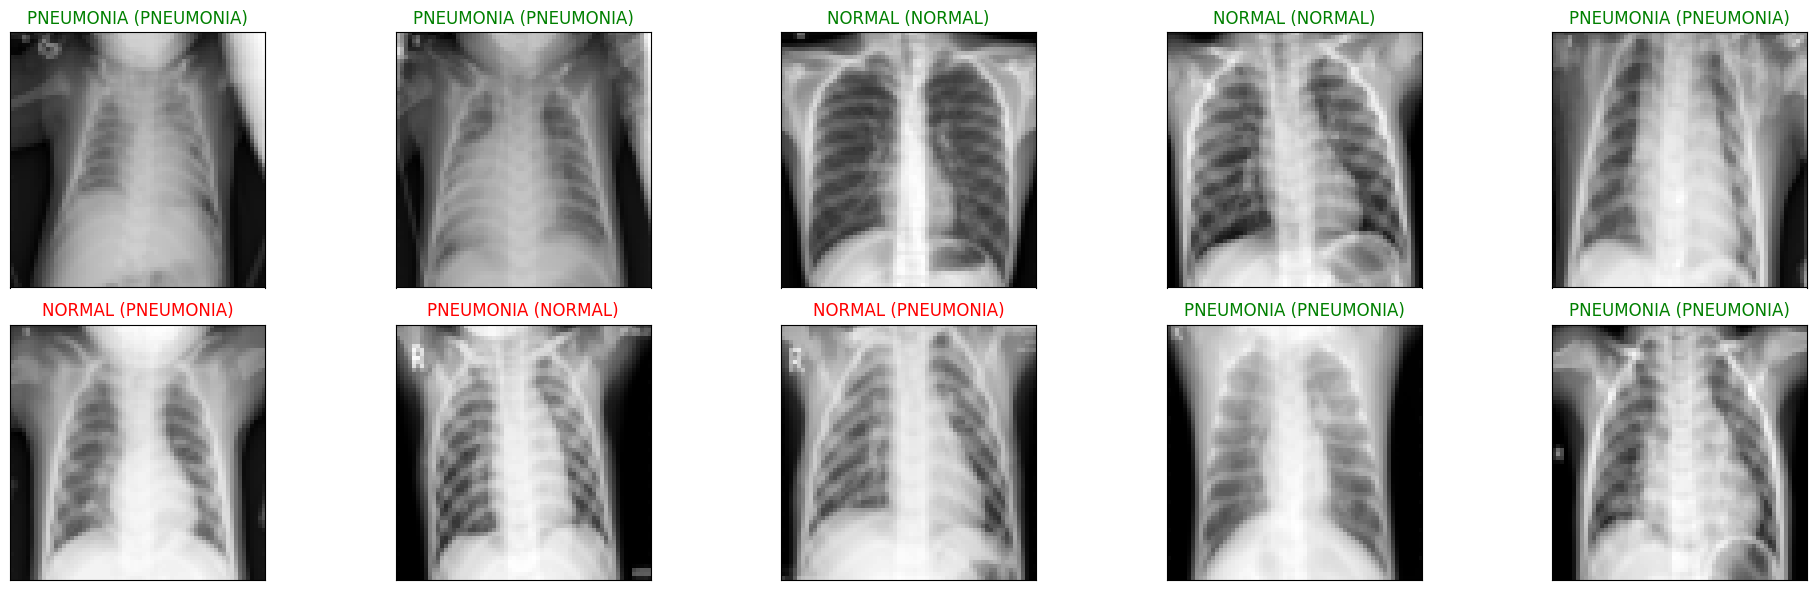

In [68]:
# --- Create a shuffled copy of the test loader just for visualization ---
# (We keep the original test_loader with shuffle=False for evaluation)
test_loader_vis = DataLoader(test_data, batch_size=10, shuffle=True)

# Get one random batch of test images
dataiter = iter(test_loader_vis)
images, labels = next(dataiter)

# Move tensors to GPU if available
images = images.to(device)
labels = labels.to(device)

# --- Run the model on this batch ---
modelB.eval()
with torch.no_grad():
    outputs = modelB(images)
    _, preds_tensor = torch.max(outputs, 1)

# Move predictions and labels back to CPU for plotting
preds = preds_tensor.cpu().numpy()
labels = labels.cpu().numpy()
images = images.cpu().numpy()

# --- Plot images with predicted and true labels ---
fig = plt.figure(figsize=(20, 6))
for idx in np.arange(len(images)):
    ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])
    
    # Unnormalize the image (reverse the normalization)
    img = np.squeeze(images[idx]) * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    
    # Define predicted and true labels
    pred_label = classes[preds[idx]]
    true_label = classes[labels[idx]]
    
    # Color the title: green = correct, red = wrong
    color = "green" if preds[idx] == labels[idx] else "red"
    ax.set_title(f"{pred_label} ({true_label})", color=color)

plt.tight_layout()
plt.show()


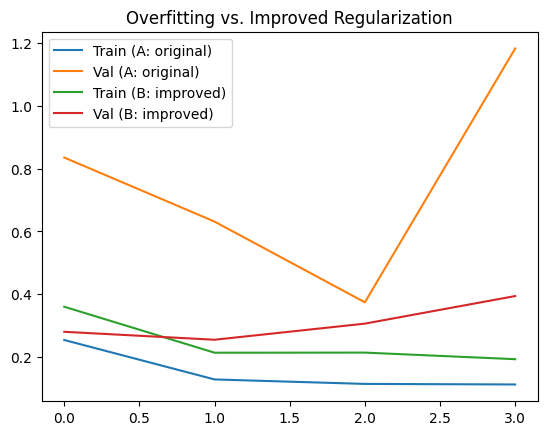

In [69]:
# Compare both training curves
plt.plot(train_losses, label='Train (A: original)')
plt.plot(val_losses, label='Val (A: original)')
plt.plot(train_losses_B, label='Train (B: improved)')
plt.plot(val_losses_B, label='Val (B: improved)')
plt.legend()
plt.title("Overfitting vs. Improved Regularization")
plt.show()


Results are still not perfect due to our reduced image size and few epochs, but a lot improved compared to the naive setup beforehand. If you have a powerful hardware available for training, why don't you increase the image resolution and train longer for comparison?

Great job! You have successfully trained an advanced convolutional neural network to detect pneunomia in xray images and handled class imbalance.